In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
btc = yf.download('BTC-USD', start='2020-01-01')
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [3]:
btc['Daily Return'] = btc['Close'].pct_change() * 100
btc[['Close', 'Daily Return']].head()

Price,Close,Daily Return
Ticker,BTC-USD,
Date,,
2020-01-01,7200.174316,NaN
2020-01-02,6985.470215,-2.981929
2020-01-03,7344.884277,5.145166
2020-01-04,7410.656738,0.895487
2020-01-05,7411.317383,0.008915


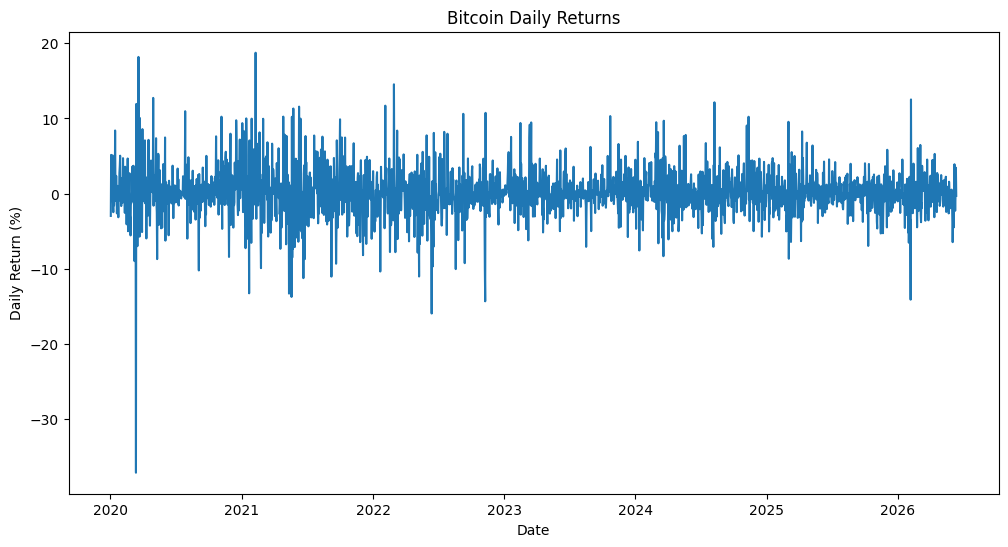

In [4]:
plt.figure(figsize=(12,6))

plt.plot(btc['Daily Return'])

plt.title('Bitcoin Daily Returns')

plt.xlabel('Date')

plt.ylabel('Daily Return (%)')

plt.show()

In [5]:
btc['EMA20'] = btc['Close'].ewm(span=20).mean()

btc['EMA50'] = btc['Close'].ewm(span=50).mean()

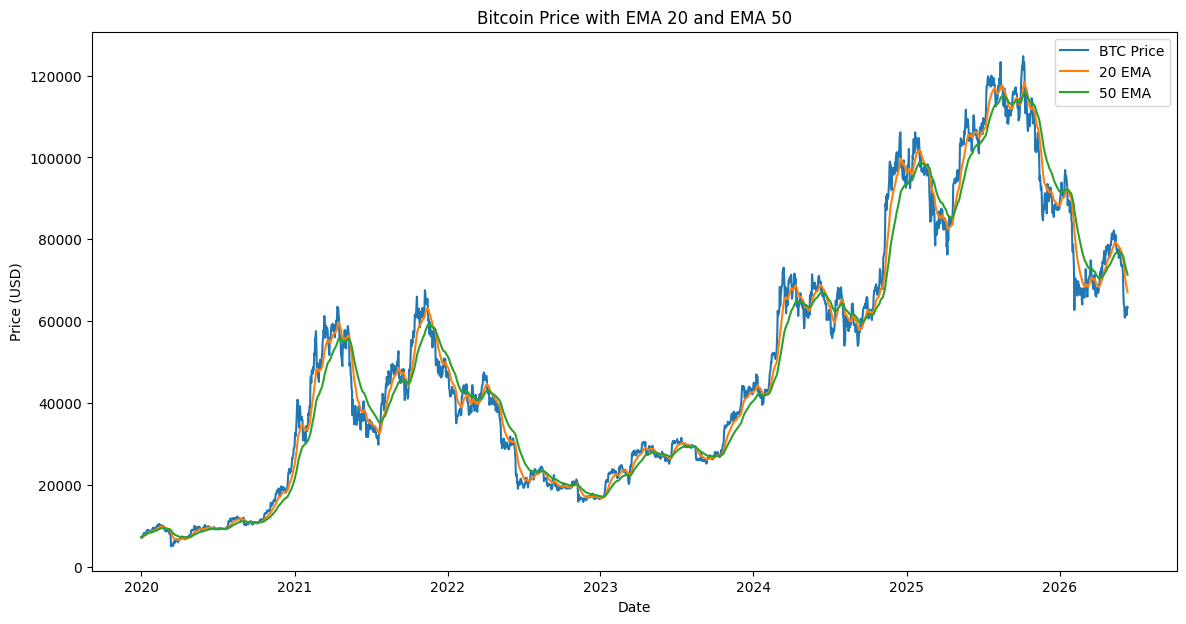

In [7]:
plt.figure(figsize=(14,7))

plt.plot(btc['Close'], label='BTC Price')
plt.plot(btc['EMA20'], label='20 EMA')
plt.plot(btc['EMA50'], label='50 EMA')

plt.title('Bitcoin Price with EMA 20 and EMA 50')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()

plt.savefig('../images/ema_analysis.png')

plt.show()

## EMA Trend Analysis

### Objective
Analyze Bitcoin price trends using Exponential Moving Averages (EMA).

### Methodology
- Calculated 20-day EMA to capture short-term trends.
- Calculated 50-day EMA to capture medium-term trends.
- Compared crossovers to identify bullish and bearish phases.

### Insights
- Bullish trends occurred when EMA20 crossed above EMA50.
- Bearish phases were observed when EMA20 moved below EMA50.
- EMA indicators effectively highlighted major Bitcoin market cycles.

In [8]:
# Calculate 30-day rolling volatility
btc['Volatility'] = btc['Daily Return'].rolling(window=30).std()

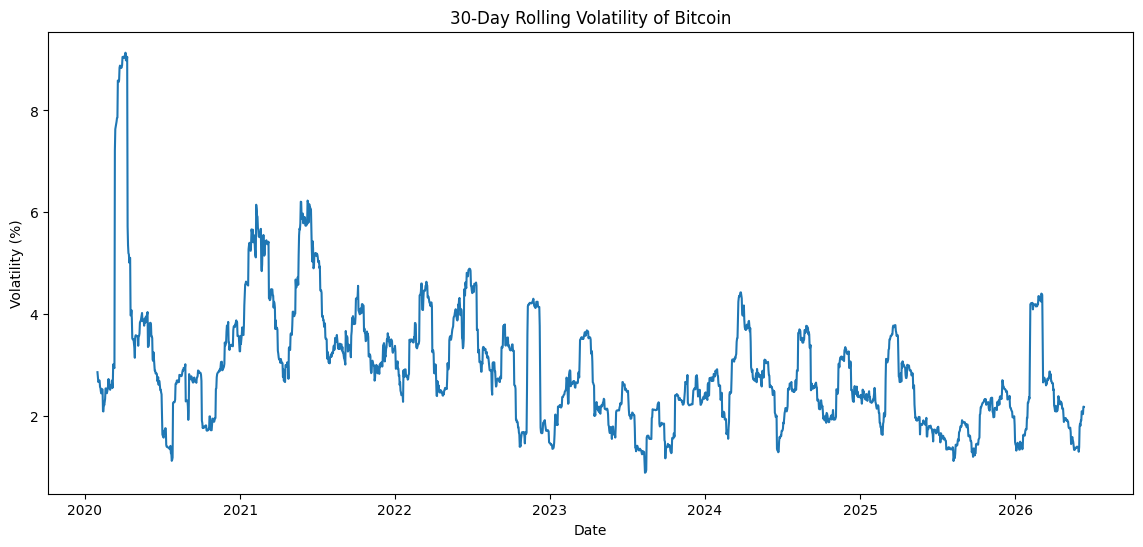

In [12]:
plt.figure(figsize=(14,6))

plt.plot(btc['Volatility'])

plt.title('30-Day Rolling Volatility of Bitcoin')

plt.xlabel('Date')

plt.ylabel('Volatility (%)')

plt.savefig('../images/volatility_analysis.png')

plt.show()

In [10]:
# Best day
best_day = btc['Daily Return'].max()

# Worst day
worst_day = btc['Daily Return'].min()

print("Best Daily Return:", best_day)

print("Worst Daily Return:", worst_day)

Best Daily Return: 18.746473766529938
Worst Daily Return: -37.169538560117076


In [11]:
print("Best Day:")
print(btc[btc['Daily Return'] == best_day][['Close', 'Daily Return']])

print("\nWorst Day:")
print(btc[btc['Daily Return'] == worst_day][['Close', 'Daily Return']])

Best Day:
Price              Close Daily Return
Ticker           BTC-USD             
Date                                 
2021-02-08  46196.464844    18.746474

Worst Day:
Price             Close Daily Return
Ticker          BTC-USD             
Date                                
2020-03-12  4970.788086   -37.169539


In [17]:
import os
import matplotlib.pyplot as plt

# Create Images folder if it doesn't exist
os.makedirs('../Images', exist_ok=True)

# 1. Bitcoin Price Trend
plt.figure(figsize=(12,6))
plt.plot(btc['Close'])
plt.title('Bitcoin Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.savefig('../Images/bitcoin_price_trend.png')
plt.close()

# 2. Daily Returns
plt.figure(figsize=(12,6))
plt.plot(btc['Daily Return'])
plt.title('Bitcoin Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.savefig('../Images/daily_returns.png')
plt.close()

# 3. EMA Analysis
plt.figure(figsize=(14,7))
plt.plot(btc['Close'], label='BTC Price')
plt.plot(btc['EMA20'], label='20 EMA')
plt.plot(btc['EMA50'], label='50 EMA')
plt.title('Bitcoin Price with EMA 20 and EMA 50')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.savefig('../Images/ema_analysis.png')
plt.close()

# 4. Volatility Analysis
plt.figure(figsize=(14,6))
plt.plot(btc['Volatility'])
plt.title('30-Day Rolling Volatility of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.savefig('../Images/volatility_analysis.png')
plt.close()

print("✅ All images saved successfully in the Images folder!")

✅ All images saved successfully in the Images folder!
